# Meeting Context, Couple Type, and Relationship Stability

This notebook explores a sociological question: **does the context in which couples meet relate to relationship stability, and does that pattern differ between different-sex and same-sex couples?**

Compared with the earlier clustering notebook, this version takes a more direct approach. Rather than discovering groups with unsupervised learning, it compares a richer set of interpretable meeting pathways that are already present in the survey.

## 1. Setup

We load the survey data and import the libraries used for cleaning, weighted summaries, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()

/tmp/ipykernel_23932/631946569.py:7: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()


## 2. Research Framing

This notebook is descriptive, not causal.

That means the goal is to show how meeting context, couple type, and later outcomes are associated in the survey data. It does **not** claim that meeting context by itself causes relationship stability.

A second important note is terminology. The survey variable used here distinguishes **same-sex couples** from **not same-sex couples**. For interpretation, that is closer to a *couple type* measure than a full identity measure such as LGBTQ identity.

## 3. Build the Analysis Variables

We recreate a broader set of meeting-context indicators from the survey items and add couple type and relationship stability variables.

In [2]:
meeting_groups = {
    "met_social_network": [
        "w1_q24_met_through_friend",
        "w1_q24_met_through_family",
        "w1_q24_met_through_as_nghbrs"
    ],
    "met_work": [
        "w1_q24_met_as_through_cowork",
        "w1_q24_customer",
        "w1_q24_work_neighbors",
        "w1_q24_business_trip"
    ],
    "met_leisure_public": [
        "w1_q24_bar_restaurant",
        "w1_q24_party",
        "w1_q24_public"
    ],
    "met_formal_intro": [
        "w1_q24_blind_date",
        "w1_q24_singles_serve_nonint"
    ],
    "met_travel": [
        "w1_q24_vacation"
    ],
    "met_online": [
        "w1_q24_met_online",
        "w1_q24_metonline_no_phone_apps",
        "w1_q24_internet_dating",
        "w1_q24_internet_soc_network",
        "w1_q24_internet_other",
        "w1_q24_internet_game",
        "w1_q24_internet_chat",
        "w1_q24_internet_org"
    ]
}

meeting_labels = {
    "met_social_network": "Social network",
    "met_work": "Workplace",
    "met_leisure_public": "Leisure/public",
    "met_formal_intro": "Formal introduction",
    "met_travel": "Travel",
    "met_online": "Online"
}

meeting_cols = list(meeting_groups.keys())
binary_cols = sorted({col for cols in meeting_groups.values() for col in cols if col in df.columns})

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
        .fillna(0)
        .astype(int)
    )

# Collapse detailed survey items into broader meeting pathways.
for meeting_col, source_cols in meeting_groups.items():
    available_cols = [col for col in source_cols if col in df.columns]
    df[meeting_col] = (df[available_cols].sum(axis=1) > 0).astype(int)

df["couple_type"] = (
    df["w1_same_sex_couple"]
    .astype(str)
    .str.strip()
    .map({
        "NOT same-sex souple": "Different-sex couples",
        "same_sex_couple": "Same-sex couples"
    })
)

# In the original notebook, a missing breakup source/year is treated as still together.
df["still_together_w3"] = df["w3_breakup_source"].isna().astype(int)
df["still_together_w2"] = df["w2_breakup_year"].isna().astype(int)

meeting_group_sources = pd.Series({
    meeting_labels[key]: ", ".join(value)
    for key, value in meeting_groups.items()
}, name="survey_items")

meeting_group_sources

Social network         w1_q24_met_through_friend, w1_q24_met_through_...
Workplace              w1_q24_met_as_through_cowork, w1_q24_customer,...
Leisure/public         w1_q24_bar_restaurant, w1_q24_party, w1_q24_pu...
Formal introduction       w1_q24_blind_date, w1_q24_singles_serve_nonint
Travel                                                   w1_q24_vacation
Online                 w1_q24_met_online, w1_q24_metonline_no_phone_a...
Name: survey_items, dtype: str

## 4. Helper Functions

These small functions keep the analysis readable and make it easier to compute weighted shares and weighted means.

In [3]:
def weighted_distribution(frame, group_col, weight_col):
    temp = frame[[group_col, weight_col]].dropna().copy()
    out = temp.groupby(group_col, observed=False)[weight_col].sum()
    return (out / out.sum()).sort_values(ascending=False)


def weighted_mean_by_group(frame, group_col, value_col, weight_col):
    temp = frame[[group_col, value_col, weight_col]].dropna().copy()
    out = (
        temp.groupby(group_col, observed=False)
        .apply(lambda x: np.average(x[value_col], weights=x[weight_col]))
        .rename(value_col)
    )
    return out


def weighted_meeting_shares(frame, couple_col, meeting_cols, weight_col):
    rows = []
    temp = frame[[couple_col, weight_col] + meeting_cols].dropna(subset=[couple_col, weight_col]).copy()
    for meeting_col in meeting_cols:
        sub = temp.dropna(subset=[meeting_col]).copy()
        summary = (
            sub.groupby(couple_col, observed=False)
            .apply(lambda x: np.average(x[meeting_col], weights=x[weight_col]))
            .rename("share")
            .reset_index()
        )
        summary["meeting_type"] = meeting_labels[meeting_col]
        rows.append(summary)
    out = pd.concat(rows, ignore_index=True)
    return out[[couple_col, "meeting_type", "share"]]


def weighted_stability_by_meeting(frame, meeting_cols, couple_col, outcome_col, weight_col):
    rows = []
    base = frame[[couple_col, outcome_col, weight_col] + meeting_cols].dropna(subset=[couple_col, outcome_col, weight_col]).copy()
    for meeting_col in meeting_cols:
        sub = base[base[meeting_col] == 1].copy()
        summary = (
            sub.groupby(couple_col, observed=False)
            .apply(lambda x: np.average(x[outcome_col], weights=x[weight_col]))
            .rename("stability_rate")
            .reset_index()
        )
        summary["meeting_type"] = meeting_labels[meeting_col]
        rows.append(summary)
    out = pd.concat(rows, ignore_index=True)
    return out[[couple_col, "meeting_type", "stability_rate"]]

## 5. Sample Composition: Why Weights Matter

The survey intentionally includes more same-sex couples than their share in the broader population. That makes subgroup analysis possible, but it also means we should distinguish between:

- the **sample composition** we observe directly
- the **weighted composition** meant to better represent the target population

This is the clearest place to visualize the role of weights.

In [4]:
unweighted_couple_share = (
    df["couple_type"]
    .dropna()
    .value_counts(normalize=True)
    .rename("share")
    .sort_index()
)

weighted_couple_share = weighted_distribution(df, "couple_type", "w1_weight_combo").sort_index()

composition = pd.DataFrame({
    "Unweighted sample": unweighted_couple_share,
    "Weighted population estimate": weighted_couple_share
})

composition

,Unweighted sample,Weighted population estimate
couple_type,,
Different-sex couples,0.909252,0.974631
Same-sex couples,0.090748,0.025369


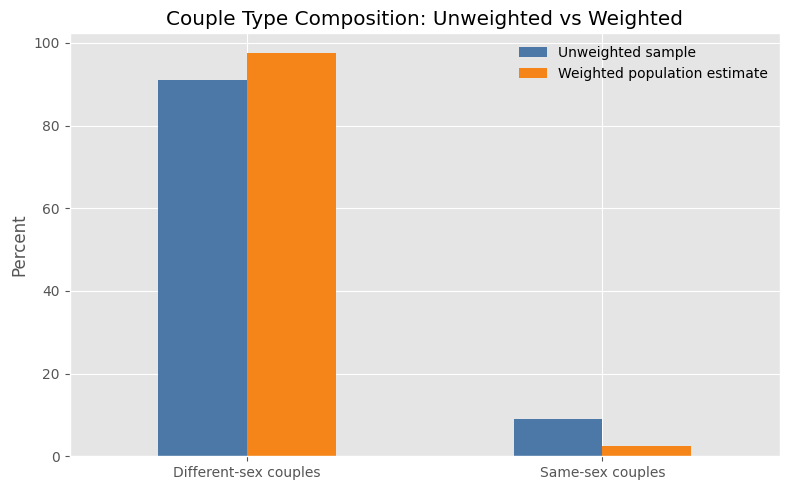

In [5]:
ax = (composition * 100).plot(kind="bar", figsize=(8, 5), color=["#4C78A8", "#F58518"])
ax.set_title("Couple Type Composition: Unweighted vs Weighted")
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. How Do Couples Meet?

Next we compare the weighted share of couples who met through each reconstructed pathway.
These categories are not mutually exclusive at the survey-item level, so they should be read as broad descriptive channels rather than perfectly exclusive types.

In [6]:
meeting_share_weighted = weighted_meeting_shares(
    df,
    couple_col="couple_type",
    meeting_cols=meeting_cols,
    weight_col="w1_weight_combo"
)

meeting_share_weighted_pivot = meeting_share_weighted.pivot(
    index="meeting_type",
    columns="couple_type",
    values="share"
)

meeting_share_weighted_pivot

couple_type,Different-sex couples,Same-sex couples
meeting_type,,
Formal introduction,0.036871,0.010186
Leisure/public,0.295395,0.368986
Online,0.096135,0.302198
Social network,0.390211,0.279582
Travel,0.012136,0.014357
Workplace,0.234411,0.156013


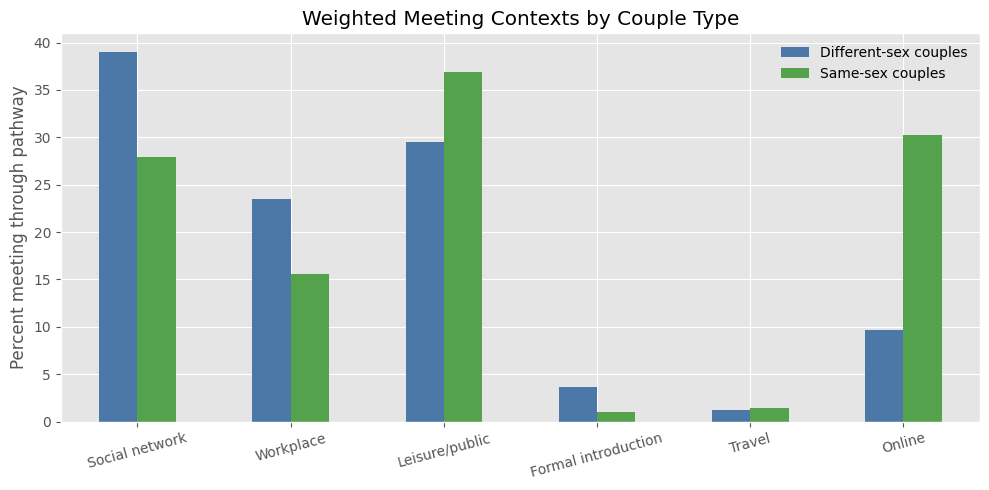

In [7]:
meeting_order = [meeting_labels[col] for col in meeting_cols]
meeting_share_weighted_pivot = meeting_share_weighted_pivot.reindex(meeting_order)

ax = (meeting_share_weighted_pivot * 100).plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#54A24B"])
ax.set_title("Weighted Meeting Contexts by Couple Type")
ax.set_ylabel("Percent meeting through pathway")
ax.set_xlabel("")
ax.legend(title="", frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Overall Stability by Couple Type

Before splitting by meeting pathway, it helps to compare overall stability rates between couple types.

Here we use wave-specific weights for wave-specific outcomes:

- `w2_combo_weight` for the wave 2 follow-up outcome
- `w3_combo_weight` for the wave 3 follow-up outcome

In [8]:
overall_w2 = weighted_mean_by_group(df, "couple_type", "still_together_w2", "w2_combo_weight")
overall_w3 = weighted_mean_by_group(df, "couple_type", "still_together_w3", "w3_combo_weight")

overall_stability = pd.DataFrame({
    "Still together by wave 2": overall_w2,
    "Still together by wave 3": overall_w3
})

overall_stability

,Still together by wave 2,Still together by wave 3
couple_type,,
Different-sex couples,0.896334,0.930903
Same-sex couples,0.785521,0.924928


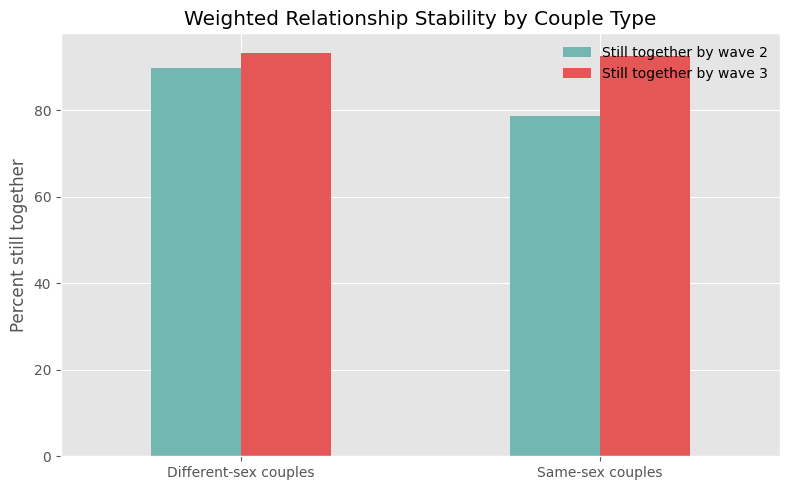

In [9]:
ax = (overall_stability * 100).plot(kind="bar", figsize=(8, 5), color=["#72B7B2", "#E45756"])
ax.set_title("Weighted Relationship Stability by Couple Type")
ax.set_ylabel("Percent still together")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Stability Within Each Meeting Pathway

This is the key comparison for the research question.

Instead of asking only whether same-sex and different-sex couples differ overall, we ask whether the relationship between meeting pathway and stability looks similar across couple types.

In [10]:
stability_w3_by_meeting = weighted_stability_by_meeting(
    df,
    meeting_cols=meeting_cols,
    couple_col="couple_type",
    outcome_col="still_together_w3",
    weight_col="w3_combo_weight"
)

stability_w3_pivot = stability_w3_by_meeting.pivot(
    index="meeting_type",
    columns="couple_type",
    values="stability_rate"
)

stability_w3_pivot

couple_type,Different-sex couples,Same-sex couples
meeting_type,,
Formal introduction,0.956265,1.000000
Leisure/public,0.936411,0.978013
Online,0.865428,0.864439
Social network,0.930302,0.931039
Travel,0.979356,0.213509
Workplace,0.957908,1.000000


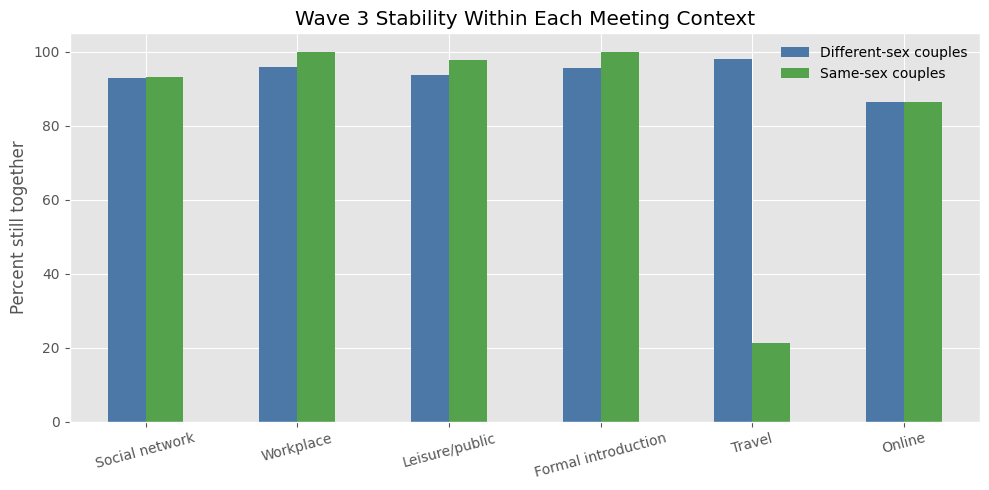

In [11]:
stability_w3_pivot = stability_w3_pivot.reindex(meeting_order)

ax = (stability_w3_pivot * 100).plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#54A24B"])
ax.set_title("Wave 3 Stability Within Each Meeting Context")
ax.set_ylabel("Percent still together")
ax.set_xlabel("")
ax.legend(title="", frameon=False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. A Compact Table for Interpretation

This final table combines the two main descriptive pieces:

- how common each meeting pathway is within each couple type
- how stable those relationships look by wave 3

It can help when writing conclusions or preparing slides.

In [12]:
summary_table = meeting_share_weighted.merge(
    stability_w3_by_meeting,
    on=["couple_type", "meeting_type"],
    how="left"
)

summary_table["meeting_type"] = pd.Categorical(
    summary_table["meeting_type"],
    categories=meeting_order,
    ordered=True
)
summary_table = summary_table.sort_values(["meeting_type", "couple_type"])

summary_table["share"] = (summary_table["share"] * 100).round(1)
summary_table["stability_rate"] = (summary_table["stability_rate"] * 100).round(1)

summary_table.rename(columns={
    "share": "Weighted share meeting this way (%)",
    "stability_rate": "Still together by wave 3 (%)"
})

,couple_type,meeting_type,Weighted share meeting this way (%),Still together by wave 3 (%)
0,Different-sex couples,Social network,39.0,93.0
1,Same-sex couples,Social network,28.0,93.1
2,Different-sex couples,Workplace,23.4,95.8
3,Same-sex couples,Workplace,15.6,100.0
4,Different-sex couples,Leisure/public,29.5,93.6
5,Same-sex couples,Leisure/public,36.9,97.8
6,Different-sex couples,Formal introduction,3.7,95.6
7,Same-sex couples,Formal introduction,1.0,100.0
8,Different-sex couples,Travel,1.2,97.9
9,Same-sex couples,Travel,1.4,21.4


## 10. Interpretation Notes

A careful conclusion from this notebook would sound something like this:

Different-sex and same-sex couples appear to use social, workplace, leisure/public, formal-introduction, travel, and online meeting contexts in different proportions, and those contexts may also be associated with different later stability patterns. These differences are descriptive and should be interpreted cautiously, especially where subgroup counts are small.

If you wanted to extend this notebook later, good next steps would be:

- checking subgroup sample sizes explicitly before drawing strong conclusions
- adding confidence intervals or standard errors
- testing whether the same descriptive patterns hold when controlling for age, marriage, or relationship duration